In [13]:
import phylodata
from src.datasets.load_phylodata import load_phylodata_experiments

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from tqdm import tqdm
from src.datasets.load_trees import load_trees_from_file

from src.distribution_analysis.process_tree import get_clade_split_df, get_observed_nodes
from src.utils.tree_utils import get_taxa_names

In [14]:
sns.set_style("darkgrid")
sns.set_theme("notebook")

sns.set_palette("colorblind")

FIG_WIDTH = 5
TITLE_FONT_SIZE = 13
LABEL_FONT_SIZE = 12

In [15]:
PLOT_DIRECTORY = Path("plots/phylodata_analysis_plots")
PLOT_DIRECTORY.mkdir(parents=True, exist_ok=True)

### Load phylodata experiments

In [16]:
phylodata.prefer_preview()
experiments = load_phylodata_experiments()

100%|██████████| 21/21 [00:00<00:00, 74.43it/s]


In [17]:
experiment_trees = {}

SAMPLE_SIZE = 10_000

for experiment in tqdm(experiments):
    try:
        tree_file = experiment.get_file_of_type(phylodata.FileType.POSTERIOR_TREES)
        trees = load_trees_from_file(tree_file.local_path)
        if SAMPLE_SIZE < len(trees):
            trees = np.random.choice(trees, SAMPLE_SIZE, replace=False).tolist()
        experiment_trees[experiment.experiment.human_readable_id] = trees
    except Exception as error:
        print(error)
        pass

100%|██████████| 21/21 [00:18<00:00,  1.15it/s]

Syntax error in tree description: STATE_0 [&lnP=-6726.3625413800055,posterior=-6726.


In [18]:
short_experiment_ids = {
    experiment_id: f"PD{i + 1}" for i, experiment_id in enumerate(experiment_trees.keys())
}
num_experiments = len(short_experiment_ids)

### Collect clades and clade splits for each experiment

In [19]:
clade_dfs = []

for experiment in tqdm(experiment_trees.keys()):
    exp_trees = experiment_trees[experiment]
    taxa_names = get_taxa_names(exp_trees[0])
    observed_nodes, observed_splits = get_observed_nodes(exp_trees, taxa_names)
    clade_df = get_clade_split_df(observed_splits)
    
    clade_df["experiment_id"] = experiment
    
    clade_dfs.append(clade_df)

clade_df = pd.concat(clade_dfs)

100%|██████████| 20/20 [00:04<00:00,  4.15it/s]


In [20]:
clade_df["height"] = clade_df["tree_height"] - clade_df["height"]
clade_df["left_height"] = clade_df["height"] - clade_df["left_branch"]
clade_df["right_height"] = clade_df["height"] - clade_df["right_branch"]
clade_df["parent_height"] = clade_df["height"] + clade_df["branch_to_parent"]

### Investigate global correlations between different variables

In [21]:
MIN_NUM_OBSEVRATIONS = 5

In [22]:
CORRELATION_ANALYSES = {
    "Sibling Branches": ["left_branch", "right_branch"],
    "Child Parent Branch": ["branch_to_parent", "left_branch"],
    "Branch and Tree Height": ["branch_to_parent", "tree_height"],
    "Branch and Height": ["branch_to_parent", "height"],
    "Sibling Heights": ["left_height", "right_height"],
    "Child Parent Heights": ["parent_height", "height"],
    "Height and Tree Height": ["height", "tree_height"],
}

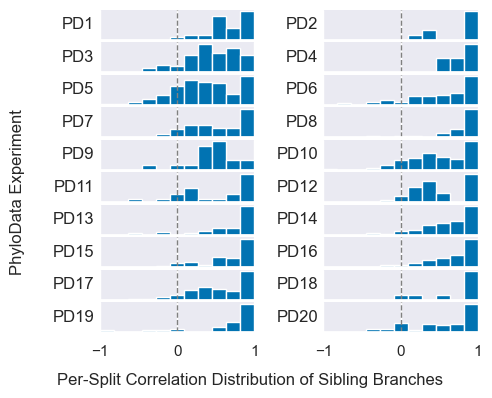

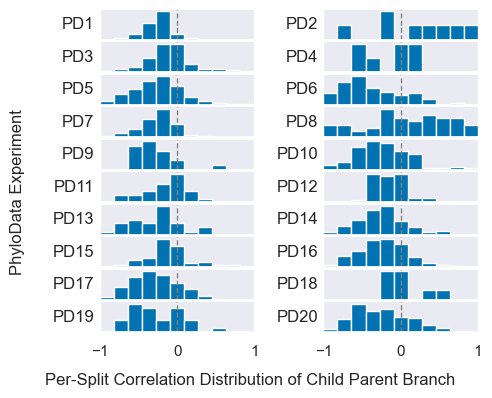

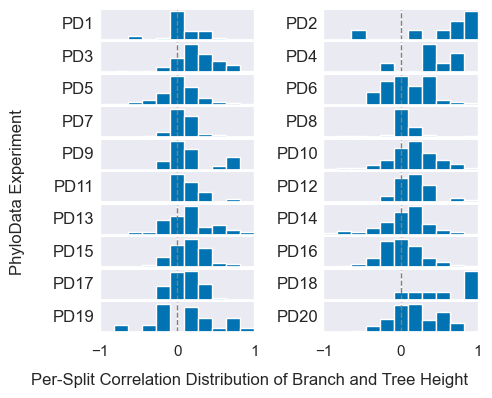

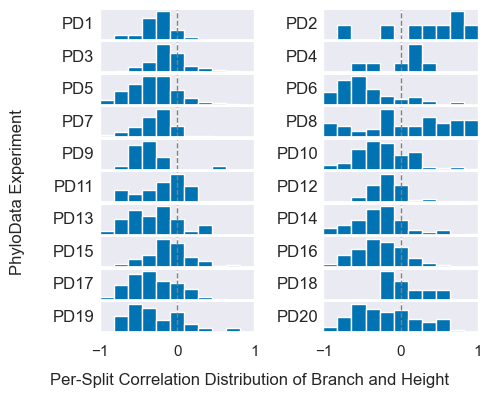

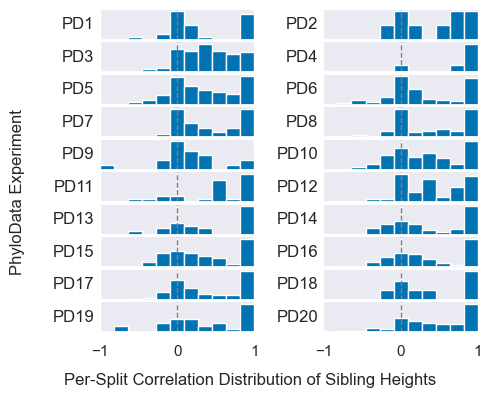

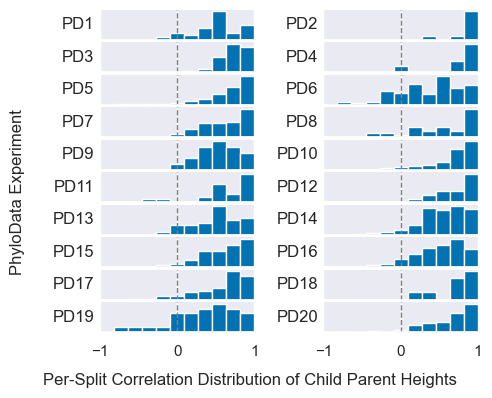

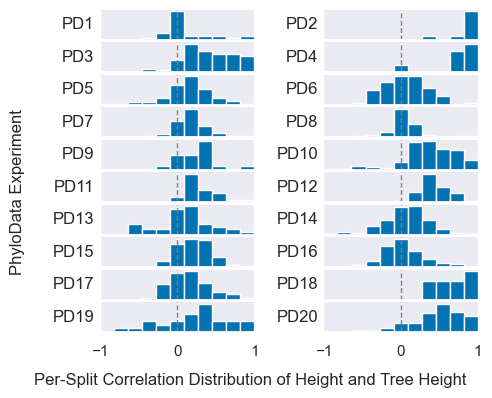

In [23]:
for analysis_name, columns in CORRELATION_ANALYSES.items():
    clade_corrs = []
    for exp_id, group in clade_df.groupby("experiment_id"):
        for clade, clade_group in group.groupby("clade_split"):
            if clade_group[columns].shape[0] > MIN_NUM_OBSEVRATIONS:
                corr = clade_group[columns].corr().iloc[0, 1]
            else:
                corr = np.nan
            clade_corrs.append({
                "experiment_id": exp_id,
                "clade": clade,
                "corr": corr
            })
    clade_corrs_df = pd.DataFrame(clade_corrs)

    # Define two columns for the grid
    ncols = 2
    nrows = int(np.ceil(num_experiments / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_WIDTH, nrows * 0.4),
        sharex=True
    )

    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for idx, (ax, exp_id) in enumerate(zip(axes_flat, short_experiment_ids)):
        data = clade_corrs_df.loc[clade_corrs_df["experiment_id"] == exp_id, "corr"].dropna()
        ax.hist(data, bins=np.linspace(-1, 1, 12))
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)  # Add a line for x=0
        ax.set_ylabel(short_experiment_ids[exp_id], rotation=0, ha='right', va='center')
        ax.set_yticks([])
        ax.set_xlim(-1, 1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

    fig.supxlabel("Per-Split Correlation Distribution of " + analysis_name, fontsize=LABEL_FONT_SIZE)
    fig.supylabel("PhyloData Experiment", fontsize=LABEL_FONT_SIZE)
    plt.tight_layout()

    plt.subplots_adjust(hspace=0.1, bottom=0.15, left=0.2)

    plt.savefig(PLOT_DIRECTORY / f"{analysis_name}.svg", bbox_inches = "tight", dpi=150)
    plt.show()

### Investigate correlations along the tree between different variables

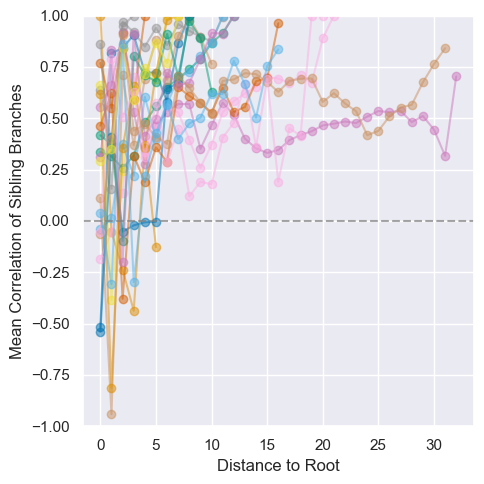

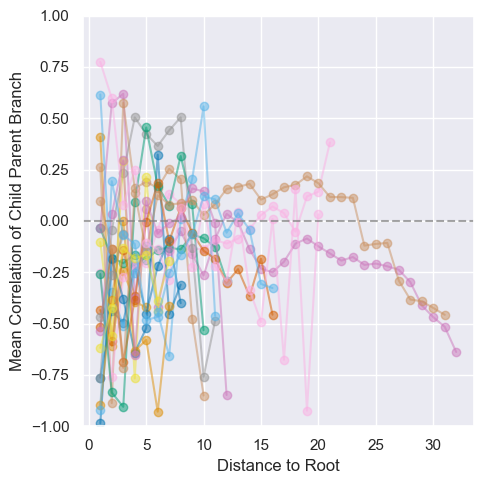

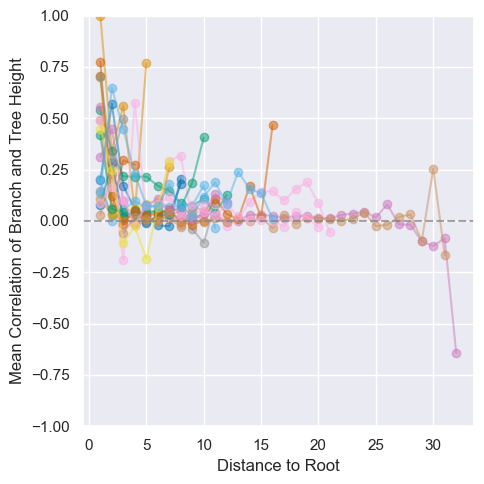

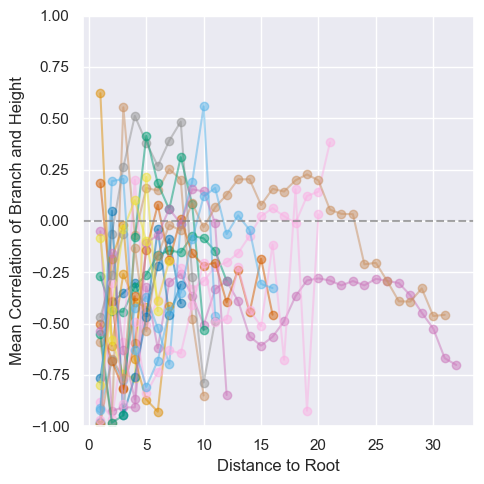

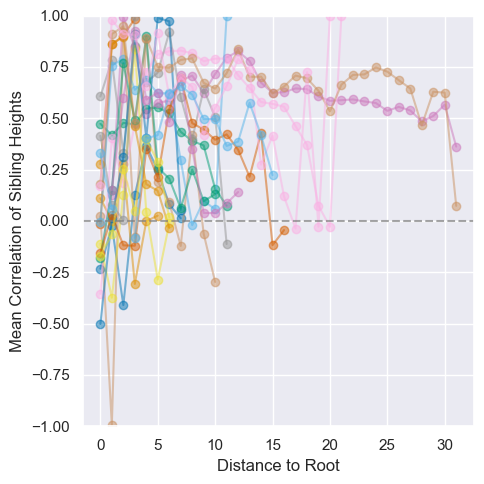

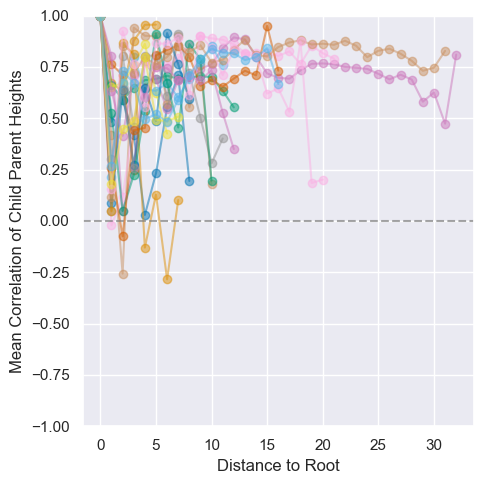

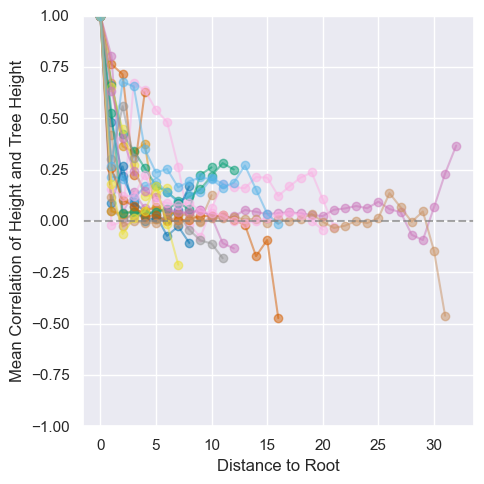

In [24]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

for analysis_name, (col_1, col_2) in CORRELATION_ANALYSES.items():
    plt.figure(figsize=(FIG_WIDTH, FIG_WIDTH))

    for exp_id, short_exp_id in short_experiment_ids.items():
        exp_group = clade_df[clade_df.experiment_id == exp_id]
        distance_vals = np.sort(exp_group["distance_to_root"].unique())
        
        corrs = []
        valid_distances = []
        for dist in distance_vals:
            subset = exp_group[exp_group["distance_to_root"] == dist]
        
            # Only calculate if there are enough values
            if subset[col_1].nunique() > 1 and subset[col_2].nunique() > MIN_NUM_OBSEVRATIONS:
                r, _ = pearsonr(subset[col_1], subset[col_2])
                corrs.append(r)
                valid_distances.append(dist)
            else:
                # Not enough data to calculate a correlation
                corrs.append(np.nan)
                valid_distances.append(dist)
        
        plt.plot(valid_distances, corrs, marker='o', label=short_exp_id, alpha=0.5)

    plt.ylim(-1, 1)
    plt.axhline(0, color='grey', linestyle='--', alpha=0.7)

    plt.xlabel("Distance to Root")
    plt.ylabel("Mean Correlation of " + analysis_name)
    
    plt.tight_layout()

    plt.savefig(PLOT_DIRECTORY / f"{analysis_name} Along the Tree.svg", bbox_inches = "tight")
    plt.show()